# Project 7: Transformer from Scratch

Building a Transformer model from scratch for IMDB sentiment classification. This is the architecture behind BERT, GPT, and all modern AI.

**Concepts Covered:**
- Self-Attention mechanism (Query, Key, Value)
- Multi-Head Attention
- Positional Encoding (word order without recurrence)
- Residual connections and Layer Normalization
- Transformer blocks
- Padding masks
- Comparison: LSTM vs Transformer

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import math
import re
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
Using device: cuda
GPU: Tesla T4


---
## Part A: Understanding Self-Attention

The core idea: every word looks at ALL other words simultaneously to understand context.

```
"The cat sat down"

For the word "sat":
  Query asks: "Who is relevant to me?"
  Keys answer: each word advertises what it contains
  Score: Q dot K = how relevant each word is
  Output: weighted sum of Values based on scores

  Result: "sat" now KNOWS about "cat" and "down" — it has context!
```

### LSTM vs Transformer
```
LSTM:        word1 -> word2 -> word3 -> word4  (sequential, slow)
Transformer: word1, word2, word3, word4 ALL AT ONCE (parallel, fast)
```

In [3]:
# Step-by-step Self-Attention demonstration
torch.manual_seed(42)
seq_length = 4
d_model = 8

# Simulated word embeddings for "The cat sat down"
X = torch.randn(1, seq_length, d_model)
print(f"Input shape: {X.shape} (1 sentence, 4 words, 8-dim each)")

# Step 1: Create Query, Key, Value
W_q = nn.Linear(d_model, d_model, bias=False)
W_k = nn.Linear(d_model, d_model, bias=False)
W_v = nn.Linear(d_model, d_model, bias=False)

Q = W_q(X)    # What am I looking for?
K = W_k(X)    # What do I contain?
V = W_v(X)    # What do I offer?
print(f"\nQ, K, V shapes: {Q.shape}")

# Step 2: Attention scores = Q dot K^T / sqrt(d_k)
scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_model)
print(f"\nAttention scores (4x4 — each word vs every other word):")
print(scores[0].detach().numpy().round(2))

# Step 3: Softmax -> attention weights (each row sums to 1)
attention_weights = torch.softmax(scores, dim=-1)
print(f"\nAttention weights (after softmax):")
print(attention_weights[0].detach().numpy().round(3))

# Step 4: Weighted sum of values
output = torch.matmul(attention_weights, V)
print(f"\nOutput shape: {output.shape}")
print("Each word now has context from all other words!")

Input shape: torch.Size([1, 4, 8]) (1 sentence, 4 words, 8-dim each)

Q, K, V shapes: torch.Size([1, 4, 8])

Attention scores (4x4 — each word vs every other word):
[[ 0.44  0.01 -0.14  0.21]
 [-0.23  0.04 -0.07  0.25]
 [ 0.12 -0.21 -0.2  -0.87]
 [-0.1   0.34  0.66  0.01]]

Attention weights (after softmax):
[[0.333 0.217 0.185 0.265]
 [0.196 0.257 0.231 0.316]
 [0.356 0.255 0.257 0.132]
 [0.172 0.268 0.367 0.193]]

Output shape: torch.Size([1, 4, 8])
Each word now has context from all other words!


---
## Part B: Full Transformer Model

### Architecture
```
Input indices
  -> Embedding + Positional Encoding
  -> [Multi-Head Attention -> Add & Norm -> Feed Forward -> Add & Norm] x N
  -> Global Average Pooling
  -> Classifier
  -> Output
```

In [4]:
# ============================================
# Transformer Components — Built from Scratch
# ============================================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        batch_size, seq_length, d_model = x.shape

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        # Split into multiple heads
        Q = Q.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        K = K.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

        # Attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        context = torch.matmul(attention_weights, V)

        # Concatenate heads
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_length, d_model)
        output = self.W_o(context)
        return output


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff, dropout)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Self-attention + residual + norm
        attended = self.attention(x, mask)
        x = self.norm1(x + self.dropout(attended))

        # Feed forward + residual + norm
        fed_forward = self.ff(x)
        x = self.norm2(x + self.dropout(fed_forward))
        return x


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


print("Transformer components defined!")

Transformer components defined!


In [5]:
# ============================================
# Full Transformer Classifier
# ============================================

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff, num_layers, num_classes,
                 max_len=512, pad_idx=0, dropout=0.1):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # Padding mask
        mask = (x != 0).unsqueeze(1).unsqueeze(2)

        # Embedding + positional encoding
        x = self.embedding(x)
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # Transformer blocks
        for block in self.transformer_blocks:
            x = block(x, mask)

        # Global average pooling
        x = x.mean(dim=1)

        # Classify
        output = self.classifier(x)
        return output

print("TransformerClassifier defined!")

TransformerClassifier defined!


---
## Load IMDB Data (Same as Project 6)

In [6]:
# Load IMDB
dataset = load_dataset("imdb")

def simple_tokenizer(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text.split()

# Build vocab
print("Building vocabulary...")
counter = Counter()
for sample in dataset['train']:
    counter.update(simple_tokenizer(sample['text']))

vocab_list = ['<pad>', '<unk>'] + [word for word, count in counter.most_common(25000)]
word2idx = {word: idx for idx, word in enumerate(vocab_list)}
VOCAB_SIZE = len(word2idx)
PAD_IDX = word2idx['<pad>']
UNK_IDX = word2idx['<unk>']
print(f"Vocabulary size: {VOCAB_SIZE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Building vocabulary...
Vocabulary size: 25002


In [7]:
class IMDBDataset(Dataset):
    def __init__(self, split='train', max_length=256):
        self.data = []
        for sample in dataset[split]:
            tokens = simple_tokenizer(sample['text'])[:max_length]
            indices = [word2idx.get(token, UNK_IDX) for token in tokens]
            if len(indices) > 0:
                self.data.append((torch.tensor(indices), sample['label']))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate_fn(batch):
    texts, labels = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor(labels, dtype=torch.long)
    return texts_padded, labels

print("Loading datasets...")
train_dataset = IMDBDataset('train', max_length=256)
test_dataset = IMDBDataset('test', max_length=256)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Loading datasets...
Train: 25000, Test: 25000


---
## Create and Train Transformer

In [8]:
model = TransformerClassifier(
    vocab_size=VOCAB_SIZE,
    d_model=128,
    num_heads=4,
    d_ff=256,
    num_layers=3,
    num_classes=2,
    max_len=256,
    pad_idx=PAD_IDX,
    dropout=0.1
).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

TransformerClassifier(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (pos_encoding): PositionalEncoding()
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer_blocks): ModuleList(
    (0-2): 3 x TransformerBlock(
      (attention): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=Fals

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

In [10]:
# Training loop
train_losses, test_losses = [], []
train_accs, test_accs = [], []
best_test_acc = 0.0
num_epochs = 10

for epoch in range(num_epochs):
    start = time.time()

    # Training
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_text, batch_labels in train_loader:
        batch_text = batch_text.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_text)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * batch_text.size(0)
        _, predicted = torch.max(outputs, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    # Evaluation
    model.eval()
    test_loss_total, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad():
        for batch_text, batch_labels in test_loader:
            batch_text = batch_text.to(device)
            batch_labels = batch_labels.to(device)
            outputs = model(batch_text)
            loss = criterion(outputs, batch_labels)
            test_loss_total += loss.item() * batch_text.size(0)
            _, predicted = torch.max(outputs, 1)
            total_test += batch_labels.size(0)
            correct_test += (predicted == batch_labels).sum().item()

    test_loss = test_loss_total / total_test
    test_acc = correct_test / total_test

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    scheduler.step(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), "best_transformer.pth")

    elapsed = time.time() - start
    print(f"Epoch {epoch+1:2d}/{num_epochs} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Loss: {train_loss:.4f} | Time: {elapsed:.1f}s")

print(f"\nBest Test Accuracy: {best_test_acc:.4f}")

Epoch  1/10 | Train Acc: 0.6610 | Test Acc: 0.7520 | Loss: 0.5945 | Time: 30.4s
Epoch  2/10 | Train Acc: 0.7737 | Test Acc: 0.7918 | Loss: 0.4741 | Time: 28.2s
Epoch  3/10 | Train Acc: 0.8041 | Test Acc: 0.7918 | Loss: 0.4257 | Time: 29.3s
Epoch  4/10 | Train Acc: 0.8204 | Test Acc: 0.8250 | Loss: 0.3980 | Time: 29.2s
Epoch  5/10 | Train Acc: 0.8358 | Test Acc: 0.8286 | Loss: 0.3718 | Time: 29.9s
Epoch  6/10 | Train Acc: 0.8499 | Test Acc: 0.8370 | Loss: 0.3501 | Time: 29.6s
Epoch  7/10 | Train Acc: 0.8560 | Test Acc: 0.8382 | Loss: 0.3325 | Time: 30.2s
Epoch  8/10 | Train Acc: 0.8637 | Test Acc: 0.8429 | Loss: 0.3166 | Time: 29.7s
Epoch  9/10 | Train Acc: 0.8716 | Test Acc: 0.8435 | Loss: 0.3019 | Time: 29.7s
Epoch 10/10 | Train Acc: 0.8782 | Test Acc: 0.8396 | Loss: 0.2911 | Time: 29.6s

Best Test Accuracy: 0.8435


---
## Evaluation

In [11]:
# Load best model
model.load_state_dict(torch.load("best_transformer.pth"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch_text, batch_labels in test_loader:
        batch_text = batch_text.to(device)
        outputs = model(batch_text)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Negative", "Positive"]))

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.85      0.84     12500
    Positive       0.85      0.84      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



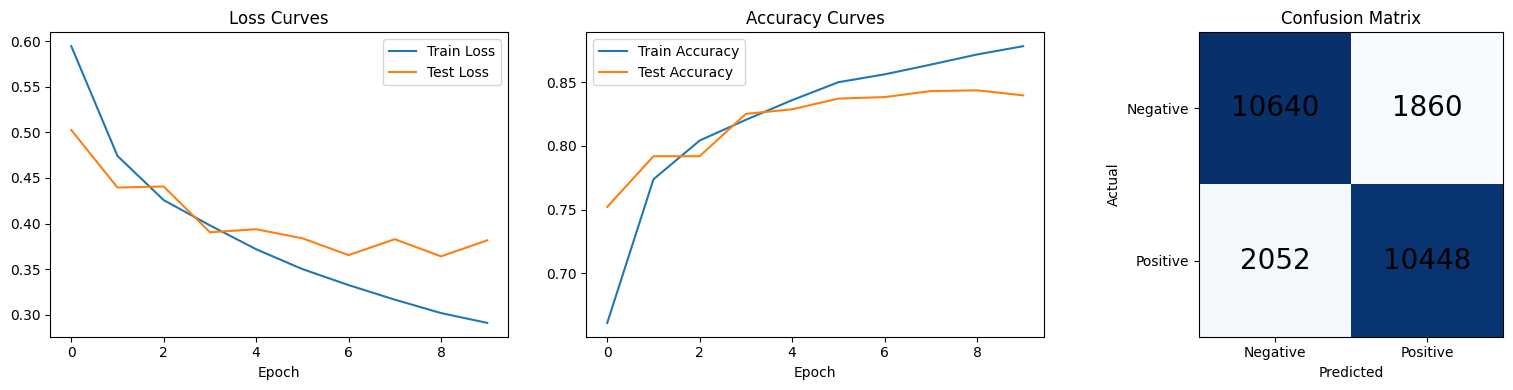

In [12]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
im = axes[2].imshow(cm, cmap="Blues")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Negative", "Positive"])
axes[2].set_yticklabels(["Negative", "Positive"])
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Actual")
axes[2].set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, cm[i][j], ha="center", va="center", fontsize=20)

plt.tight_layout()
plt.show()

---
## Test on Custom Reviews

In [13]:
def predict_review(text):
    model.eval()
    tokens = simple_tokenizer(text)[:256]
    indices = torch.tensor([word2idx.get(t, UNK_IDX) for t in tokens]).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(indices)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
    return "Positive" if pred == 1 else "Negative", probs[0][pred].item()

reviews = [
    "This movie was absolutely fantastic! Great acting and storyline.",
    "Terrible film. Worst movie I have ever seen. Complete waste of time.",
    "The movie was okay. Nothing special but not bad either.",
    "I loved every minute of this masterpiece. A must watch!",
    "Boring and predictable. The plot made no sense at all."
]

print("Custom Review Predictions:")
print("=" * 60)
for r in reviews:
    sentiment, conf = predict_review(r)
    print(f"\nReview: {r}")
    print(f"Prediction: {sentiment} (confidence: {conf:.4f})")

Custom Review Predictions:

Review: This movie was absolutely fantastic! Great acting and storyline.
Prediction: Positive (confidence: 0.7397)

Review: Terrible film. Worst movie I have ever seen. Complete waste of time.
Prediction: Negative (confidence: 0.9981)

Review: The movie was okay. Nothing special but not bad either.
Prediction: Negative (confidence: 0.9976)

Review: I loved every minute of this masterpiece. A must watch!
Prediction: Positive (confidence: 0.9979)

Review: Boring and predictable. The plot made no sense at all.
Prediction: Negative (confidence: 0.9983)


In [14]:
# Save model
torch.save(model.state_dict(), "transformer_sentiment_final.pth")
print("Model saved!")

Model saved!


---
## Key Takeaways

### Self-Attention Formula
```
Attention(Q, K, V) = softmax(Q * K^T / sqrt(d_k)) * V

Q (Query):  What am I looking for?
K (Key):    What do I contain?
V (Value):  What do I offer?
```

### Transformer Architecture
```
Input -> Embedding + Positional Encoding
  -> [Multi-Head Attention + Residual + LayerNorm
      -> Feed Forward + Residual + LayerNorm] x N layers
  -> Global Average Pooling
  -> Classifier -> Output
```

### Concepts Learned
1. **Self-Attention** — every word attends to all other words simultaneously
2. **Query, Key, Value** — the mechanism for computing relevance between words
3. **Multi-Head Attention** — multiple attention patterns in parallel
4. **Positional Encoding** — adds word order info (sin/cos) since no recurrence
5. **Residual Connections** — x + attention(x) prevents information loss
6. **LayerNorm** — normalizes within each sample (not across batch like BatchNorm)
7. **Padding Mask** — tells attention to ignore pad tokens

### LSTM vs Transformer
```
LSTM:        Sequential processing -> slow, info fades over long sequences
Transformer: Parallel processing   -> fast, direct attention to any word
```

### Why Transformers Changed Everything
- BERT (Google): Transformer encoder for understanding text
- GPT (OpenAI): Transformer decoder for generating text
- Vision Transformer (ViT): Transformers for images
- All modern AI is built on this architecture

### Test Your Knowledge
- Explain self-attention with Q, K, V analogy
- Why positional encoding is needed (no recurrence = no word order)
- Multi-head attention: different heads learn different relationships
- Why residual connections help deep networks
- LayerNorm vs BatchNorm
- Why Transformers are faster than LSTMs (parallelization)
- How BERT and GPT relate to this architecture